In [2]:
import numpy as np
import tenpy.linalg.np_conserved as npc
from tenpy.models.spins import SpinModel
from tenpy.algorithms.exact_diag import ExactDiag

def run_kagome_ed():
    # 1. Define model parameters
    # The Kagome unit cell has 3 sites, so Lx=2, Ly=1 gives 2 * 1 * 3 = 6 sites total.
    model_params = {
        'lattice': 'Kagome',
        'Lx': 2,
        'Ly': 1,
        'S': 0.5,           # Spin-1/2
        'Jx': 1.0,          # Heisenberg isotropic couplings (J_x = J_y = J_z)
        'Jy': 1.0,
        'Jz': 1.0,
        'bc_MPS': 'finite', # Required for ExactDiag
        'bc_y': 'open',
        'conserve': 'Sz'    # Conserve total Sz to reduce the matrix size blocks
    }
    
    print("Initializing SpinModel on a Kagome lattice...")
    model = SpinModel(model_params)
    
    # 2. Pick a target charge sector (optional, but highly recommended)
    # Let's target the half-filling sector (total Sz = 0)
    # Total sites = 6, so 3 up and 3 down spins
    num_sites = model.lat.N_sites
    print(f"Total number of sites in the cluster: {num_sites}")
    
    # Let's create an initial state to extract the total charge representation
    # 'up' and 'down' repeated to fill total sites
    init_state = ['up', 'down'] * (num_sites // 2)
    
    # Construct an MPS briefly just to read out the exact charge sector representation safely
    from tenpy.networks.mps import MPS
    psi_mock = MPS.from_product_state(model.lat.mps_sites(), init_state)
    target_sector = psi_mock.get_total_charge(True)
    
    # 3. Initialize Exact Diagonalization
    print("Building full Hamiltonian from MPO inside specified charge sector...")
    ED = ExactDiag(model, charge_sector=target_sector)
    ED.build_full_H_from_mpo()
    
    # 4. Perform the full diagonalization
    print("Running exact diagonalization...")
    ED.full_diagonalization()
    
    # 5. Extract ground state and eigenvalues
    E_ground, psi_ground = ED.groundstate()
    all_eigenvalues = ED.E
    
    print("\n--- ED Results ---")
    print(f"Ground state energy: {E_ground:.8f}")
    print(f"Energy per site: {E_ground / num_sites:.8f}")
    print(f"Number of eigenvalues in this sector: {len(all_eigenvalues)}")
    print(f"Lowest 5 eigenvalues: {all_eigenvalues[:5]}")

if __name__ == "__main__":
    run_kagome_ed()

Initializing SpinModel on a Kagome lattice...
Total number of sites in the cluster: 6
Building full Hamiltonian from MPO inside specified charge sector...
Running exact diagonalization...

--- ED Results ---
Ground state energy: -2.25000000
Energy per site: -0.37500000
Number of eigenvalues in this sector: 20
Lowest 5 eigenvalues: [-2.25       -1.75       -1.75       -1.66421356 -1.56309903]


C:\Users\chait\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\tenpy\networks\mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


In [1]:
import os
# Force numpy/BLAS to use fewer threads to prevent CPU thrashing
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["OPENBLAS_NUM_THREADS"] = "6"

import csv
import time
import numpy as np
import h5py

import tenpy
from tenpy.networks.site import SpinHalfFermionSite
from tenpy.models.lattice import Kagome
from tenpy.models.model import CouplingMPOModel
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg
from tenpy.tools.hdf5_io import save

from tenpy.tools.hdf5_io import load, load_from_hdf5

import warnings

warnings.filterwarnings("ignore", message = "H is zero in the given block")
warnings.filterwarnings("ignore", message = f"unused option \['N_elec'\]")

# Ensure output directories exist
os.makedirs("data_outputs", exist_ok=True)
os.makedirs("data_outputs/wavefunctions", exist_ok=True)

# ---------------------------------------------------------
# 1. Custom Kagome Hubbard Model
# ---------------------------------------------------------
class KagomeHubbardModel(CouplingMPOModel):
    """
    Custom Kagome Fermi-Hubbard model supporting NNN hopping.
    """
    def init_sites(self, model_params):
        # SpinHalfFermionSite uses separate kwargs for particle and spin conservation
        cons_N = model_params.get('cons_N', 'N')
        cons_Sz = model_params.get('cons_Sz', 'Sz')
        return SpinHalfFermionSite(cons_N=cons_N, cons_Sz=cons_Sz)

    def init_lattice(self, model_params):
        Lx = model_params.get('Lx', 1)
        Ly = model_params.get('Ly', 1)
        bc_x = model_params.get('bc_x', 'periodic')
        bc_y = model_params.get('bc_y', 'periodic')
        site = self.init_sites(model_params)
        kagome_model = Kagome(Lx, Ly, site, bc=[bc_x, bc_y])
        return kagome_model

    def init_terms(self, model_params):
        #nearest-neighbor hopping, next-nearest-neighbor hopping, and coulomb interaction
        t1 = model_params.get('t1', 1.0)
        t2 = model_params.get('t2', 0.0)
        U = model_params.get('U', 0.0)
        
        # Site-dependent chemical potential (array of size N_sites)
        # Defaults to None, meaning 0.0 for all sites
        mu_array = model_params.get('mu', None)

        #TABC
        theta_x = model_params.get('theta_x', 0.0)
        theta_y = model_params.get('theta_y', 0.0)
        # Nearest-neighbor hopping
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            #TABC Phase
            phase = np.exp(1j * (theta_x * dx[0] + theta_y * dx[1]))
            
            self.add_coupling(-t1*phase, u1, 'Cdu', u2, 'Cu', dx, plus_hc=True)
            self.add_coupling(-t1*phase, u1, 'Cdd', u2, 'Cd', dx, plus_hc=True)

        # Next-nearest-neighbor hopping
        for u1, u2, dx in self.lat.pairs['next_nearest_neighbors']:
            #TABC Phase
            phase = np.exp(1j * (theta_x * dx[0] + theta_y * dx[1]))
            
            self.add_coupling(-t2*phase, u1, 'Cdu', u2, 'Cu', dx, plus_hc=True)
            self.add_coupling(-t2*phase, u1, 'Cdd', u2, 'Cd', dx, plus_hc=True)

        # On-site Coulomb interaction
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(U, u, 'NuNd')

        # ---------------------------------------------------------
        # SITE-DEPENDENT CHEMICAL POTENTIAL
        # ---------------------------------------------------------
        if mu_array is not None:
            # Validate array length matches total lattice sites
            if len(mu_array) != self.lat.N_sites:
                raise ValueError(f"Length of 'mu' array ({len(mu_array)}) must match total lattice sites ({self.lat.N_sites}).")
            
            # 1. Create a spatial array to match the Kagome lattice geometry
            # Shape: (Lx, Ly, num_unit_cell_sites)
            Lx, Ly = self.lat.Ls
            mu_spatial = np.zeros((Lx, Ly, len(self.lat.unit_cell)))
            
            # 2. Map the 1D MPS array into the 3D lattice array
            for i in range(self.lat.N_sites):
                # lat.mps2lat_idx(i) returns the lattice coordinates (x, y, u)
                x, y, u = self.lat.mps2lat_idx(i)
                mu_spatial[x, y, u] = mu_array[i]
                
            # 3. Apply the spatially-dependent array to each unit cell site (u)
            for u in range(len(self.lat.unit_cell)):
                # mu_spatial[:, :, u] extracts the (Lx, Ly) array of strengths for site 'u'
                # -mu * (n_up + n_dn)
                self.add_onsite(-mu_spatial[:, :, u], u, 'Ntot')
# ---------------------------------------------------------
# 2. Helpers for Initial States & Parameters
# ---------------------------------------------------------
def generate_product_state(N, N_elec):
    """
    Distributes electrons to match total N_elec while minimizing Sz.
    Creates a valid product state string for SpinHalfFermionSite.
    """
    state = ['empty'] * N
    N_up = N_elec // 2 + (N_elec % 2)
    N_down = N_elec // 2
    
    # Fill spin-ups from the left
    for i in range(N_up):
        state[i] = 'up'
    # Fill spin-downs from the right (allows double occupancy 'full' if needed)
    for i in range(N_down):
        idx = N - 1 - i
        if state[idx] == 'empty':
            state[idx] = 'down'
        else:
            state[idx] = 'full'
    return state

def get_random_U():
    """Stratified sampling for U."""
    block = np.random.choice(['weak', 'intermediate', 'strong'])
    if block == 'weak': return np.random.uniform(0.1, 2.0)
    elif block == 'intermediate': return np.random.uniform(2.0, 6.0)
    else: return np.random.uniform(6.0, 10.0)
def get_kagome_positions(model_params, L):
    """
    Reconstruct the Kagome lattice geometry from saved model_params to extract exact 2D spatial coordinates of each site
    """
    cons_N = model_params.get('cons_N', 'N')
    cons_Sz = model_params.get('cons_Sz', 'Sz')
    site = SpinHalfFermionSite(cons_N=cons_N, cons_Sz=cons_Sz)
    Lx = model_params['Lx']
    Ly = model_params['Ly']
    bc_x = model_params.get('bc_x', 'periodic')
    bc_y = model_params.get('bc_y', 'periodic')

    lattice = Kagome(Lx, Ly, site, bc=[bc_x, bc_y])

    #extract physical 2D coordinates for all L sites
    return np.array([lattice.position(lattice.mps2lat_idx(i)) for i in range(L)])

def calculate_structure_factor(correlation_matrix, positions, q_vectors):
    """
    Compute S(q) for (1/N) * sum_{j, l} exp (i * q  DOT (r_j - r_l)) * C{jl}
        1/N * Summation (j,l): ( Phase Matrix * Correlation Matrix)
    """
    N = correlation_matrix.shape[0]
    S_q = np.zeros(len(q_vectors), dtype=complex)
    #print('begin idx,q loop')
    for idx, q in enumerate(q_vectors):
        #Calculate distance vectors between all pairs of sites (r_j - r_l)
        #np.newaxis adds a new col/row to its position (:, np.newaxis, :) = (X, Y+1, Z)...
        #In this case, positions.shape = (X+N, Y+N, Z)
        r_diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
        #print('\t got r_diff')
        #calculate phase matrix: exp(i*q DOT r_diff)
        phase_matrix = np.exp(1j * np.dot(r_diff, q))
        #print('\t got phase matrix')
        #Multiple element-wise with the correlation matrix and sum
        S_q[idx] = np.sum(phase_matrix * correlation_matrix)/N
        #print(f'\t got S_q[{idx}]')
    #return the real aspects of S_q
    return np.real(S_q)
        
def measure_properties(psi, model_params, **kwargs):
    #print(f"measuring properties...")
    #1.  Calculate basic observables mapping out charge and spin densities
    charge_density = psi.expectation_value('Ntot') # Total particles per site
    spin_density = psi.expectation_value('Sz')     # Sz per site
    double_occupancy = psi.expectation_value('NuNd') 
    #print("pass charge density, spin density, double occupancy")
    # 2. Compute Heavy Correlation Functions
    # Calculate Spin-Spin correlation <Sz_i Sz_j> across the whole lattice
    # Using term_correlation_function_right for optimal performance
    
    spin_corr_matrix = psi.correlation_function('Sz', 'Sz')
    
    #spin_corr_matrix = psi.term_correlation_function_right([('Sz', 0)],[('Sz', 1)])
    #print(f'spin_corr_matrix: {spin_corr_matrix}')
    #print(f'shape: {spin_corr_matrix.shape}')
    #print("pass spin correlation matrix")
    # Calculate Charge-Charge correlation <N_i N_j>

    charge_corr_matrix = psi.correlation_function('Ntot', 'Ntot')
    
    #charge_corr_matrix = psi.term_correlation_function_right([('Ntot', 0)],[('Ntot', 1)])
    #print("pass charge correlation matrix")
    # Calculate Structure Factors (Requires Fourier transforming the correlation matrix)
    # Example: Simple sum of spin-spin correlations as a scalar placeholder
    #S_q_zero = np.sum(spin_corr_matrix)

    #Structure Factors: reconstruct site positions
    positions = get_kagome_positions(model_params, psi.L)
    #print("pass position kagome")
    #define momentum vectors from -pi to pi
    #ADJUST DENSITY
    momentum_density = kwargs.get("momentum_density", 20)
    qx = np.linspace(-np.pi, np.pi, momentum_density)
    qy = np.linspace(-np.pi, np.pi, momentum_density)
    QX, QY = np.meshgrid(qx, qy)
    q_vectors = np.column_stack([QX.ravel(), QY.ravel()])
    #print("pass q vectors")
    #Spin Structure Factor:
    S_q_spin = calculate_structure_factor(spin_corr_matrix, positions, q_vectors)
    S_q_charge = calculate_structure_factor(charge_corr_matrix, positions, q_vectors)
    #print(f"meaured properties")
    return {
        "charge_density": charge_density,
        "double_occupancy": double_occupancy,
        "spin_corr": spin_corr_matrix,
        "charge_corr": charge_corr_matrix,
        "q_vectors": q_vectors,
        "S_q_spin": S_q_spin,
        "S_q_charge": S_q_charge
    }

def load_and_measure(run_id, h5_filepath, **kwargs):
    """
    Loads a highly optimized MPS and computes custom correlation matrices.
    """
    print(f"Loading {run_id}...")
    
    # 1. Reconstruct MPS from HDF5
    # TeNPy's load function takes the string path directly
    #data = load(h5_filepath)
    
    #psi = data['psi']
    #model_params = data['model_params']
    with h5py.File(h5_filepath, 'r') as f_h5:
        #data = load(f_h5)
        psi = load_from_hdf5(f_h5, 'psi')
        model_params = load_from_hdf5(f_h5, 'model_params')
    
    # Calculate basic observables mapping out charge and spin densities
    charge_density = psi.expectation_value('Ntot') # Total particles per site
    spin_density = psi.expectation_value('Sz')     # Sz per site
    double_occupancy = psi.expectation_value('NuNd') 

    # 2. Compute Heavy Correlation Functions
    # Calculate Spin-Spin correlation <Sz_i Sz_j> across the whole lattice
    # Using term_correlation_function_right for optimal performance
    spin_corr_matrix = psi.term_correlation_function_right([('Sz', 0)],[('Sz', 1)])
    
    # Calculate Charge-Charge correlation <N_i N_j>
    charge_corr_matrix = psi.term_correlation_function_right([('Ntot', 0)],[('Ntot', 1)])
    
    # Calculate Structure Factors (Requires Fourier transforming the correlation matrix)
    # Example: Simple sum of spin-spin correlations as a scalar placeholder
    #S_q_zero = np.sum(spin_corr_matrix)

    #Structure Factors: reconstruct site positions
    positions = get_kagome_positions(model_params, psi.L)

    #define momentum vectors from -pi to pi
    #ADJUST DENSITY
    momentum_density = kwargs.get("momentum_density", 20)
    qx, qy = np.linspace(-np.pi, np.pi, momentum_density)
    QX, QY = np.meshgrid(qx, qy)
    q_vectors = np.column_stack([QX.ravel(), QY.ravel()])

    #Spin Structure Factor:
    S_q_spin = compute_structure_factor(spin_corr_matrix, positions, q_vectors)
    S_q_charge = compute_structure_factor(charge_corr_matrix, positions, q_vectors)
    
    
    # 3. Export Data for the AI Agent
    # In a real workflow, you would save these arrays directly into standard .npy files
    print(f"--- Analysis for {run_id} ---")
    print(f"System Size: {psi.L} sites")
    print(f"Average Double Occupancy: {np.mean(double_occupancy):.4f}")
    print(f"S_q Spin Structure Factor: {S_q_spin}\n")
    print(f"S_q Charge Structure Factor: {S_q_charge}\n")
    print(f"Model Parameters: {model_params}\n")

    print(f"Appending observables to {run_id}.h5")

    #open file in append mode
    with h5py.File(h5_filepath, 'a') as f_h5:
        if 'observables' in f_h5:
            print(f"observables already exist: delete and re-append")
            del f_h5['observables']

        obs_group = f_h5.create_group('observables')
        obs_group['spin_corr_matrix'] = spin_corr_matrix
        obs_group['charge_corr_matrix'] = charge_corr_matrix
        obs_group['charge_density'] = charge_density
        obs_group['double_occupancy'] = double_occupancy
        obs_group['q_vectors'] = q_vectors #shape (400, 2) 400 dependant on momentum density
        obs_group['S_q_spin'] = S_q_spin #shape (400, x)
        obs_group['S_q_charge'] = S_q_charge #shape(400, x)
    print(f"\tAppended!\n")
    return {
        "charge_density": charge_density,
        "double_occupancy": double_occupancy,
        "spin_corr": spin_corr_matrix,
        "charge_corr": charge_corr_matrix
    }
def apply_geometric_symmetrization(observables, model_params, psi) -> dict:
    """
    Applies real-space geometric symmetrization to local observables and 
    correlation matrices based on lattice site distances.
    """
    site_positions = get_kagome_positions(model_params, psi.L)
    num_sites = len(site_positions)
    symmetrized = observables.copy()  # Preserve keys we don't modify (like q_vectors)

    # 1. Symmetrize Local Observables (Site-Averaging)
    # Checks for local phenomenon
    local_keys = ['charge_density', 'double_occupancy']
    
    for key in local_keys:
        if key in observables and observables[key] is not None:
            val_array = np.array(observables[key])
            avg_val = np.mean(val_array)
            symmetrized[key] = [float(avg_val)] * num_sites

    # 2. Symmetrize Correlation Matrices (Distance-Averaging)
    matrix_keys = ['spin_corr', 'charge_corr']              # matrix names
    
    # Pre-compute distance groups for the given geometry
    distance_groups = {}
    for i in range(num_sites):
        for j in range(num_sites):
            dist = np.linalg.norm(site_positions[i] - site_positions[j])
            # Round distance to 5 decimals to handle floating point noise
            dist_key = np.round(dist, decimals=5)
            
            if dist_key not in distance_groups:
                distance_groups[dist_key] = []
            distance_groups[dist_key].append((i, j))

    # Apply distance-averaging to any matrices found in the dictionary
    for key in matrix_keys:
        if key in observables and observables[key] is not None:
            matrix = np.array(observables[key])
            sym_matrix = np.zeros_like(matrix)
            
            for dist_key, pairs in distance_groups.items():
                # Find the mean correlation for all site pairs at this exact distance
                avg_val = np.mean([matrix[i, j] for i, j in pairs])
                
                # Assign the averaged value back to all corresponding pairs
                for i, j in pairs:
                    sym_matrix[i, j] = float(avg_val)
                    
            symmetrized[key] = sym_matrix.tolist()
            
    return symmetrized


In [11]:
import os
import csv
import time
import numpy as np
import h5py

import tenpy
from tenpy.networks.site import SpinHalfFermionSite
from tenpy.models.lattice import Kagome
from tenpy.models.model import CouplingMPOModel
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg
from tenpy.tools.hdf5_io import save

trial_geometry = (1,1)
trial_filling = 1.0
trial_lx, trial_ly = trial_geometry
trial_N_sites = 3 * trial_lx * trial_ly
trial_U = 0.0
trial_t1 = 1.0
trial_t2 = 1.0

trial_N_elec = 2
try:     
    trial_model_params = {
        'Lx': trial_lx, 'Ly': trial_ly,
        'bc_x': 'open', 'bc_y': 'open',
        't1': trial_t1, 't2': trial_t2, 'U': trial_U,
        'cons_N': 'N',     # Conservations split for SpinHalfFermionSite
        'cons_Sz': 'Sz'
    }
    
    #start_time = time.time()
    trial_energy, trial_max_err = np.nan, np.nan
    trial_converged = False
    
    
    # 1. Build Model
    trial_model = KagomeHubbardModel(trial_model_params)
    
    # 2. Build Initial State
    trial_init_str = generate_product_state(trial_N_sites, trial_N_elec)
    trial_psi = MPS.from_product_state(trial_model.lat.mps_sites(), trial_init_str, trial_model.lat.bc_MPS, unit_cell_width=trial_model.lat.N_sites)
    
    # 3. Configure DMRG (CPU optimized)
    trial_dmrg_params = {
        'mixer': True,
        'max_E_err': 1e-6,
        'trunc_params': {
            'chi_max': 400, # Conservative bound for laptop memory
            'svd_min': 1e-10
        },
        'max_sweeps': 30 # Allows time for long-range PBC correlations to converge
    }
    
    # 4. Run DMRG Engine
    trial_eng = dmrg.TwoSiteDMRGEngine(trial_psi, trial_model, trial_dmrg_params)
    trial_energy, trial_max_err = trial_eng.run()
    trial_converged = True
    print(f'Energy: {trial_energy}')
except Exception as e:
    print(f"Error: {e}")

Energy: -4.0


In [70]:
# ---------------------------------------------------------
# 3. Main Generation Loop
# ---------------------------------------------------------
def main():
    num_samples = 100
    # Lx, Ly tuples matching N = 3, 6, 9, 12, 15 (Kagome has 3 sites/unit cell)
    geometries = [(1,1), (2,1), (3,1), (2,2), (4,1)]
    filling_targets = [0.333, 0.417, 0.5, 0.8, 1.0, 1.2]
    
    #csv_file = "data_outputs/master_index.csv"
    #csv_file = "data_outputs/three_sites_index.csv"
    #csv_file = "data_outputs/six_sites_index.csv"
    csv_file = "data_outputs/nine_sites_index.csv"
    #csv_file = "data_outputs/twelve_sites_index.csv"
    
    # Initialize CSV
    with open(csv_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Run_ID", "Lx", "Ly", "N_sites", "t1", "t2", "U", 
                         "Target_Filling", "N_elec", "Energy", "Max_Err", 
                         "Converged", "Duration_sec"])

    print(f"Starting dataset generation of {num_samples} configurations...")

    for i in range(num_samples):
        run_id = f"Kagome_Hubbard_{i:03d}"
        print(f"\n--- Running {run_id} ---")
        
        # Sample parameters
        Lx, Ly = geometries[np.random.choice(len(geometries))]

        #CHOOSE SPECIFIC GEOMETRIES
        #Lx, Ly = (1,1)
        #Lx, Ly = (2,1)
        Lx, Ly = (3,1)
        
        N_sites = 3 * Lx * Ly
        t1 = 1.0
        t2 = np.random.uniform(-0.3, 0.3)
        U = get_random_U()
        #weak/moderate interactions (U/t2 < 6.0)
        #while U/t2 >= 6.0:
        #    U = get_random_U()
        filling = np.random.choice(filling_targets)
        N_elec = max(1, min(int(round(filling * N_sites)), 2 * N_sites))
        
        model_params = {
            'Lx': Lx, 'Ly': Ly,
            'bc_x': 'periodic', 'bc_y': 'periodic',
            't1': t1, 't2': t2, 'U': U,
            'cons_N': 'N',     # Conservations split for SpinHalfFermionSite
            'cons_Sz': 'Sz'
        }
        
        start_time = time.time()
        energy, max_err = np.nan, np.nan
        converged = False
        
        try:
            # 1. Build Model
            model = KagomeHubbardModel(model_params)
            
            # 2. Build Initial State
            init_str = generate_product_state(N_sites, N_elec)
            psi = MPS.from_product_state(model.lat.mps_sites(), init_str, model.lat.bc_MPS, unit_cell_width=model.lat.N_sites)
            
            # 3. Configure DMRG (CPU optimized)
            dmrg_params = {
                'mixer': True,
                'max_E_err': 1e-6,
                'trunc_params': {
                    'chi_max': 400, # Conservative bound for laptop memory
                    'svd_min': 1e-10
                },
                'max_sweeps': 30 # Allows time for long-range PBC correlations to converge
            }
            
            # 4. Run DMRG Engine
            eng = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
            energy, max_err = eng.run()
            converged = True
            
            # 5. Serialize Wavefunction
            # Utilizing TeNPy's HDF5 wrapper ensures proper tensor reconstruction ADDING ENERGY TO THE LIST
            h5_path = f"data_outputs/wavefunctions/nine_site_{run_id}.h5"
            #with h5py.File(h5_path, 'w') as f_h5:
                #save(f_h5, {'psi': psi, 'model_params': model_params})
            save({'psi': psi, 'model_params': model_params, 'energy':energy}, h5_path)
                
        except Exception as e:
            print(f"Warning: Configuration {run_id} failed. Reason: {e}")
            converged = False
            
        duration = time.time() - start_time
        print(f"Result: E={energy:.6f}, N={N_sites}, N_elec={N_elec}, U={U:.2f} | Time: {duration:.1f}s")
        
        # 6. Save Metadata
        with open(csv_file, modef='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([run_id, Lx, Ly, N_sites, t1, t2, U, 
                             filling, N_elec, energy, max_err, 
                             converged, duration])

if __name__ == "__main__":
    main()

Starting dataset generation of 100 configurations...

--- Running Kagome_Hubbard_000 ---


KeyboardInterrupt: 

In [3]:
#TAKE 2
# ---------------------------------------------------------
# 3. Main Generation Loop
# ---------------------------------------------------------
def main():
    #return
    num_samples = 200
    # Lx, Ly tuples matching N = 3, 6, 9, 12, 15 (Kagome has 3 sites/unit cell)
    geometries = [(1,1), (2,1), (3,1), (2,2), (4,1)]
    filling_targets = [0.333, 0.417, 0.5, 0.8, 1.0, 1.2]
    
    #csv_file = "data_outputs/master_index.csv"
    csv_file = "data_outputs/three_sites_index.csv"
    #csv_file = "data_outputs/six_sites_index.csv"
    #csv_file = "data_outputs/nine_sites_index.csv"
    #csv_file = "data_outputs/twelve_sites_index.csv"
    
    # Initialize CSV
    with open(csv_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Run_ID", "Lx", "Ly", "N_sites", "t1", "t2", "U", 
                         "Target_Filling", "N_elec", "Energy_0", "Average_Energy", "MPS_Info",
                         "Converged", "Duration_sec"])

    print(f"Starting dataset generation of {num_samples} configurations...")

    start_final_time = time.time()
    
    for i in range(num_samples):
        j = i
        run_id = f"{j:03d}"
        print(f"\n--- Running Kagome Hubbard {run_id} ---")
        
        # Sample parameters
        #Lx, Ly = geometries[np.random.choice(len(geometries))]

        #CHOOSE SPECIFIC GEOMETRIES
        Lx, Ly = (1,1)
        #Lx, Ly = (2,1)
        #Lx, Ly = (3,1)
        
        N_sites = 3 * Lx * Ly
        t1 = 1.0
        t2 = np.random.uniform(-0.3, 0.3)
        U = get_random_U()
        #weak/moderate interactions (U/t2 < 6.0)
        #while U/t2 >= 6.0:
        #    U = get_random_U()
        filling = np.random.choice(filling_targets)
        N_elec = max(1, min(int(round(filling * N_sites)), 2 * N_sites))

        bc_x = 'periodic' if Lx > 1 else 'open'
        bc_y = 'periodic' if Ly > 1 else 'open'

        epsilon = 1e-5
        mu_array = np.zeros(N_sites)
        mu_array[0] = epsilon  # Match the pinning field on Site 0
        
        model_params = {
            'Lx': Lx, 'Ly': Ly,
            'bc_x': bc_x, 'bc_y': bc_y,
            't1': t1, 't2': t2, 'U': U,
            'cons_N': 'N',     # Conservations split for SpinHalfFermionSite
            'cons_Sz': 'Sz',
            'N_elec': N_elec,
            'theta_x': 0.0,
            'theta_y': 0.0,
            'mu': mu_array
        }
        
        start_time = time.time()
        energy = np.nan
        converged = False

        #TABC
        avg_energy = 0.0
        energy_zero = np.nan
        avg_props = None
        props_zero = None
        model_params_zero = None
        psi_zero = None
        info = None

        #twists
        twists = [(0.0, 0.0), (np.pi, 0.0), (0.0, np.pi), (np.pi, np.pi)]
        #twists = [(0.0, 0.0)]
        
        try:
            for theta_x, theta_y in twists:
                print(f"Computing Twist: theta_x = {theta_x:.2f}, theta_y = {theta_y:.2f}")
                
                #0.5: Update model params
                model_params['theta_x'] = theta_x
                model_params['theta_y'] = theta_y
                
                # 1. Build Model
                model = KagomeHubbardModel(model_params)
                
                # 2. Build Initial State
                init_str = generate_product_state(N_sites, N_elec)
                psi = MPS.from_product_state(model.lat.mps_sites(), init_str, model.lat.bc_MPS, unit_cell_width=model.lat.N_sites)
                
                # 3. Configure DMRG (CPU optimized)
                dmrg_params = {
                    'mixer': True,
                    'mixer_params': {
                        'amplitude': 1e-3,
                        'decay': 1.2,
                        'disable_after': 30
                    },
                    #'max_E_err': 1e-6,
                    'trunc_params': {
                        'chi_max': 400, # Conservative bound for laptop memory
                        #'chi_min': 50,      # Let it drop down if entanglement is low
                        #'trunc_cut': 1e-8,  # Truncate aggressively based on weight
                        'svd_min': 1e-10,
                        'trunc_cut': 1e-10
                    },
                    'max_sweeps': 60 # Allows time for long-range PBC correlations to converge
                    #'update_env': 0
                }
                
                # 4. Run DMRG Engine
                eng = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
                energy, info = eng.run()
                #print("energy: ", energy)
                converged = True

                #save first energy/psi
                if (theta_x, theta_y) == (0.0, 0.0):
                    energy_zero = energy
                    psi_zero = psi.copy()
                    model_params_zero = model_params.copy()
                    #print(f"first set, theta 0")
                #max_err = eng.sweep_stats.get('max_trunc_err', [0.0])[-1]
                #print(f"max-err: {max_err}")
                #max_err = info.get('max_trunc_err', 0.0)
                #final_max_err = max(final_max_err, max_err)

                #properties/observables for twist
                props = measure_properties(psi, model_params)
                #print(f"pass measuring properties")

                if (theta_x, theta_y) == (0.0, 0.0):
                    props_zero = props
                if avg_props is None:
                    avg_props = {k: v/4.0 for k, v in props.items()}
                else:
                    for k in avg_props:
                        avg_props[k] += props[k] /4.0
                

                #average energies
                avg_energy += energy/4
                
                
            # 5. Serialize Wavefunction
            # Utilizing TeNPy's HDF5 wrapper ensures proper tensor reconstruction ADDING ENERGY TO THE LIST
            file_name = f"three_site_kagome_{run_id}.h5"
            #file_name = f"six_site_kagome_{run_id}.h5"
            #file_name = f"nine_site_kagome_{run_id}.h5"
            h5_path = f"data_outputs/wavefunctions/{file_name}"
            
            #h5_path = f"data_outputs/wavefunctions/three_site_{run_id}.h5"
            #h5_path = f"data_outputs/wavefunctions/six_site_{run_id}.h5"
            #h5_path = f"data_outputs/wavefunctions/nine_site_kagome_{run_id}.h5"

            #h5_path = f"data_outputs/wavefunctions/three_site_kagome_t2_{t2}_u_{U}.h5"
            #h5_path = f"data_outputs/wavefunctions/six_site_kagome_t2_{t2}_u_{U}.h5"
            #h5_path = f"data_outputs/wavefunctions/nine_site_kagome_t2_{t2}_u_{U}.h5"
             
            #with h5py.File(h5_path, 'w') as f_h5:
                #save(f_h5, {'psi': psi, 'model_params': model_params})
            save({'psi': psi_zero, 'model_params': model_params_zero, 'energy':energy_zero, 'average_energy':avg_energy}, h5_path)
            
            with h5py.File(h5_path, 'r+') as f_h5:
                psi_group = f_h5['psi']
                psi_group.attrs['psi_type'] = "tenpy_mps"
                
            #open file in append mode
            with h5py.File(h5_path, 'a') as f_h5:
                if 'observables' in f_h5:
                    print(f"observables already exist: delete and re-append")
                    del f_h5['observables']

                obs_group = f_h5.create_group('observables')
                for key, array in props_zero.items():
                    obs_group[key] = array
                    
                print(f"\tAppended observables")
                if 'average_observables' in f_h5:
                    print(f"average_observables already exist: delete and re-append")
                    del f_h5['average_observables']

                obs_group = f_h5.create_group('average_observables')
                for key, array in avg_props.items():
                    obs_group[key] = array
                    
                print(f"\tAppended average_observables")

            print(f"H5 File: {file_name}")
            
            
            
                
        except Exception as e:
            print(f"Warning: Configuration {run_id} failed. Reason: {e}")
            converged = False
            
        duration = time.time() - start_time
        current_duration = time.time() - start_final_time
        print(f"Result: E={energy_zero:.6f}, N={N_sites}, N_elec={N_elec}, U={U:.2f} | Time: {duration:.1f}s | Total Time: {current_duration:.1f}s")
        
        # 6. Save Metadata
        with open(csv_file, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([run_id, Lx, Ly, N_sites, t1, t2, U, 
                             filling, N_elec, energy_zero, avg_energy, info,
                             converged, duration])

    final_duration = time.time() - start_final_time
    print("Total Time: ", final_duration)

if __name__ == "__main__":
    main()



Starting dataset generation of 200 configurations...

--- Running Kagome Hubbard 000 ---
Computing Twist: theta_x = 0.00, theta_y = 0.00
Computing Twist: theta_x = 3.14, theta_y = 0.00
Computing Twist: theta_x = 0.00, theta_y = 3.14
Computing Twist: theta_x = 3.14, theta_y = 3.14
	Appended observables
	Appended average_observables
H5 File: three_site_kagome_000.h5
Result: E=-2.000003, N=3, N_elec=1, U=2.35 | Time: 9.4s | Total Time: 9.4s

--- Running Kagome Hubbard 001 ---
Computing Twist: theta_x = 0.00, theta_y = 0.00
Computing Twist: theta_x = 3.14, theta_y = 0.00
Computing Twist: theta_x = 0.00, theta_y = 3.14
Computing Twist: theta_x = 3.14, theta_y = 3.14
	Appended observables
	Appended average_observables
H5 File: three_site_kagome_001.h5
Result: E=-3.789586, N=3, N_elec=2, U=0.68 | Time: 4.6s | Total Time: 14.0s

--- Running Kagome Hubbard 002 ---
Computing Twist: theta_x = 0.00, theta_y = 0.00
Computing Twist: theta_x = 3.14, theta_y = 0.00
Computing Twist: theta_x = 0.00, the

In [8]:
#TESTING SCRIPT
# ---------------------------------------------------------
# 3. Main Generation Loop
# ---------------------------------------------------------
def main():
    #return
    num_samples = 1
    # Lx, Ly tuples matching N = 3, 6, 9, 12, 15 (Kagome has 3 sites/unit cell)
    geometries = [(1,1), (2,1), (3,1), (2,2), (4,1)]
    filling_targets = [0.333, 0.417, 0.5, 0.8, 1.0, 1.2]
    
    #csv_file = "data_outputs/master_index.csv"
    #csv_file = "data_outputs/three_sites_index.csv"
    #csv_file = "data_outputs/six_sites_index.csv"
    #csv_file = "data_outputs/nine_sites_index.csv"
    #csv_file = "data_outputs/twelve_sites_index.csv"
    csv_file = "data_outputs/TESTING.csv"
    
    # Initialize CSV
    with open(csv_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Run_ID", "Lx", "Ly", "N_sites", "t1", "t2", "U", 
                         "Target_Filling", "N_elec", "Energy_0", "Average_Energy", "MPS_Info",
                         "Converged", "Duration_sec"])

    print(f"Starting dataset generation of {num_samples} configurations...")

    for i in range(num_samples):
        run_id = f"Kagome_Hubbard_{i:03d}"
        print(f"\n--- Running {run_id} ---")
        
        # Sample parameters
        Lx, Ly = geometries[np.random.choice(len(geometries))]

        #CHOOSE SPECIFIC GEOMETRIES
        #Lx, Ly = (1,1)
        #Lx, Ly = (2,1)
        #Lx, Ly = (3,1)
        Lx, Ly = (2,2)
        
        N_sites = 3 * Lx * Ly
        t1 = 1.0
        #t2 = np.random.uniform(-0.3, 0.3)
        t2 = 0.0
        #U = get_random_U()
        U = 6.082
        #weak/moderate interactions (U/t2 < 6.0)
        #while U/t2 >= 6.0:
        #    U = get_random_U()
        #filling = np.random.choice(filling_targets)
        filling = 0.5
        #N_elec = max(1, min(int(round(filling * N_sites)), 2 * N_sites))
        N_elec = i+1
        
        model_params = {
            'Lx': Lx, 'Ly': Ly,
            'bc_x': 'periodic', 'bc_y': 'periodic',
            't1': t1, 't2': t2, 'U': U,
            'cons_N': 'N',     # Conservations split for SpinHalfFermionSite
            'cons_Sz': 'Sz',
            'theta_x': 0.0,
            'theta_y': 0.0
        }
        
        start_time = time.time()
        energy = np.nan
        converged = False

        #TABC
        avg_energy = 0.0
        energy_zero = np.nan
        avg_props = None
        props_zero = None
        model_params_zero = None
        psi_zero = None

        #twists
        twists = [(0.0, 0.0), (np.pi, 0.0), (0.0, np.pi), (np.pi, np.pi)]
        
        try:
            #for theta_x, theta_y in twists:
            for i in range(1):
                theta_x = 0
                theta_y = 0
                print(f"Computing Twist: theta_x = {theta_x:.2f}, theta_y = {theta_y:.2f}")
                
                #0.5: Update model params
                model_params['theta_x'] = theta_x
                model_params['theta_y'] = theta_y
                
                # 1. Build Model
                model = KagomeHubbardModel(model_params)
                
                # 2. Build Initial State
                init_str = generate_product_state(N_sites, N_elec)
                psi = MPS.from_product_state(model.lat.mps_sites(), init_str, model.lat.bc_MPS, unit_cell_width=model.lat.N_sites)
                print(f"PSI Type: {type(psi)}")
                print(f"PSI:\n{psi}")
                
                # 3. Configure DMRG (CPU optimized)
                dmrg_params = {
                    'mixer': True,
                    'mixer_params': {
                        'amplitude': 1e-4,
                        'decay': 1.2,
                        'disable_after': 20
                    },
                    'max_E_err': 1e-6,
                    'trunc_params': {
                        'chi_max': 400, # Conservative bound for laptop memory
                        #'chi_min': 50,      # Let it drop down if entanglement is low
                        'trunc_cut': 1e-8,  # Truncate aggressively based on weight
                        'svd_min': 1e-10
                    },
                    'max_sweeps': 30 # Allows time for long-range PBC correlations to converge
                }
                
                # 4. Run DMRG Engine
                eng = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
                energy, info = eng.run()
                converged = True

                #save first energy/psi
                if (theta_x, theta_y) == (0.0, 0.0):
                    energy_zero = energy
                    psi_zero = psi.copy()
                    model_params_zero = model_params.copy()
                    #print(f"first set, theta 0")
                #max_err = eng.sweep_stats.get('max_trunc_err', [0.0])[-1]
                #print(f"max-err: {max_err}")
                #max_err = info.get('max_trunc_err', 0.0)
                #final_max_err = max(final_max_err, max_err)
                #print(info)

                #properties/observables for twist
                props = measure_properties(psi, model_params)
                #print(props)
                #print(f"pass measuring properties")

                if (theta_x, theta_y) == (0.0, 0.0):
                    props_zero = props
                if avg_props is None:
                    avg_props = {k: v/4.0 for k, v in props.items()}
                else:
                    for k in avg_props:
                        avg_props[k] += props[k] /4.0
                

                #average energies
                avg_energy += energy/4
                
        
            # 5. Serialize Wavefunction
            # Utilizing TeNPy's HDF5 wrapper ensures proper tensor reconstruction ADDING ENERGY TO THE LIST
            #h5_path = f"data_outputs/wavefunctions/three_site_{run_id}.h5"
            #h5_path = f"data_outputs/wavefunctions/six_site_{run_id}.h5"
            #h5_path = f"data_outputs/wavefunctions/nine_site_{run_id}.h5"
            h5_path = f"data_outputs/wavefunctions/TESTING_{run_id}.h5"
            #with h5py.File(h5_path, 'w') as f_h5:
                #save(f_h5, {'psi': psi, 'model_params': model_params})
            save({'psi': psi_zero, 'model_params': model_params_zero, 'energy':energy_zero, 'average_energy':avg_energy}, h5_path)
            with h5py.File(h5_path, 'r+') as f_h5:
                psi_group = f_h5['psi']
                psi_group.attrs['psi_type'] = "tenpy_mps"
            #print(props_zero)
            #print(avg_props)
            #open file in append mode
            with h5py.File(h5_path, 'a') as f_h5:
                if 'observables' in f_h5:
                    print(f"observables already exist: delete and re-append")
                    del f_h5['observables']

                obs_group = f_h5.create_group('observables')
                for key, array in props_zero.items():
                    obs_group[key] = array
                    
                print(f"\tAppended observables")
                if 'average_observables' in f_h5:
                    print(f"average_observables already exist: delete and re-append")
                    del f_h5['average_observables']

                obs_group = f_h5.create_group('average_observables')
                for key, array in avg_props.items():
                    obs_group[key] = array
                    
                print(f"\tAppended average_observables")
            
            
            
                
        except Exception as e:
            print(f"Warning: Configuration {run_id} failed. Reason: {e}")
            converged = False
            
        duration = time.time() - start_time
        print(f"Result: E={energy_zero:.6f}, N={N_sites}, N_elec={N_elec}, U={U:.2f} | Time: {duration:.1f}s")
        
        # 6. Save Metadata
        with open(csv_file, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([run_id, Lx, Ly, N_sites, t1, t2, U, 
                             filling, N_elec, energy_zero, avg_energy, info,
                             converged, duration])

if __name__ == "__main__":
    main()



Starting dataset generation of 1 configurations...

--- Running Kagome_Hubbard_000 ---
Computing Twist: theta_x = 0.00, theta_y = 0.00
PSI Type: <class 'tenpy.networks.mps.MPS'>
PSI:
MPS, L=12, bc='finite'.
chi: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
first two sites: SpinHalfFermionSite('N', 'Sz', 1.000000) SpinHalfFermionSite('N', 'Sz', 1.000000)
first two forms:(0.0, 1.0) (0.0, 1.0)
	Appended observables
	Appended average_observables
Result: E=-4.000000, N=12, N_elec=1, U=6.08 | Time: 6.2s


In [5]:
import h5py
import numpy as np
from tenpy.tools.hdf5_io import load, load_from_hdf5

def get_kagome_positions(model_params, L):
    """
    Reconstruct the Kagome lattice geometry from saved model_params to extract exact 2D spatial coordinates of each site
    """
    cons_N = model_params.get('cons_N', 'N')
    cons_Sz = model_params.get('cons_Sz', 'Sz')
    site = SpinHalfFermionSite(cons_N=cons_N, cons_Sz=cons_Sz)
    Lx = model_params['Lx']
    Ly = model_params['Ly']
    bc_x = model_params.get('bc_x', 'periodic')
    bc_y = model_params.get('bc_y', 'periodic')

    lattice = Kagome(Lx, Ly, site, bc=[bc_x, bc_y])

    #extract physical 2D coordinates for all L sites
    return np.array([lattice.position(lattice.mps2lat_idx(i)) for i in range(L)])

def calculate_structure_factor(correlation_matrix, positions, q_vectors):
    """
    Compute S(q) for (1/N) * sum_{j, l} exp (i * q  DOT (r_j - r_l)) * C{jl}
        1/N * Summation (j,l): ( Phase Matrix * Correlation Matrix)
    """
    N = correlation_matrix.shape[0]
    S_q = np.zeros(len(q_vectors), dtype=complex)
    #print('begin idx,q loop')
    for idx, q in enumerate(q_vectors):
        #Calculate distance vectors between all pairs of sites (r_j - r_l)
        #np.newaxis adds a new col/row to its position (:, np.newaxis, :) = (X, Y+1, Z)...
        #In this case, positions.shape = (X+N, Y+N, Z)
        r_diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
        #print('\t got r_diff')
        #calculate phase matrix: exp(i*q DOT r_diff)
        phase_matrix = np.exp(1j * np.dot(r_diff, q))
        #print('\t got phase matrix')
        #Multiple element-wise with the correlation matrix and sum
        S_q[idx] = np.sum(phase_matrix * correlation_matrix)/N
        #print(f'\t got S_q[{idx}]')
    #return the real aspects of S_q
    return np.real(S_q)
        
def measure_properties(psi, model_params, **kwargs):
    #print(f"measuring properties...")
    #1.  Calculate basic observables mapping out charge and spin densities
    charge_density = psi.expectation_value('Ntot') # Total particles per site
    spin_density = psi.expectation_value('Sz')     # Sz per site
    double_occupancy = psi.expectation_value('NuNd') 
    #print("pass charge density, spin density, double occupancy")
    # 2. Compute Heavy Correlation Functions
    # Calculate Spin-Spin correlation <Sz_i Sz_j> across the whole lattice
    # Using term_correlation_function_right for optimal performance
    
    spin_corr_matrix = psi.correlation_function('Sz', 'Sz')
    
    #spin_corr_matrix = psi.term_correlation_function_right([('Sz', 0)],[('Sz', 1)])
    #print(f'spin_corr_matrix: {spin_corr_matrix}')
    #print(f'shape: {spin_corr_matrix.shape}')
    #print("pass spin correlation matrix")
    # Calculate Charge-Charge correlation <N_i N_j>

    charge_corr_matrix = psi.correlation_function('Ntot', 'Ntot')
    
    #charge_corr_matrix = psi.term_correlation_function_right([('Ntot', 0)],[('Ntot', 1)])
    #print("pass charge correlation matrix")
    # Calculate Structure Factors (Requires Fourier transforming the correlation matrix)
    # Example: Simple sum of spin-spin correlations as a scalar placeholder
    #S_q_zero = np.sum(spin_corr_matrix)

    #Structure Factors: reconstruct site positions
    positions = get_kagome_positions(model_params, psi.L)
    #print("pass position kagome")
    #define momentum vectors from -pi to pi
    #ADJUST DENSITY
    momentum_density = kwargs.get("momentum_density", 20)
    qx = np.linspace(-np.pi, np.pi, momentum_density)
    qy = np.linspace(-np.pi, np.pi, momentum_density)
    QX, QY = np.meshgrid(qx, qy)
    q_vectors = np.column_stack([QX.ravel(), QY.ravel()])
    #print("pass q vectors")
    #Spin Structure Factor:
    S_q_spin = calculate_structure_factor(spin_corr_matrix, positions, q_vectors)
    S_q_charge = calculate_structure_factor(charge_corr_matrix, positions, q_vectors)
    #print(f"meaured properties")
    return {
        "charge_density": charge_density,
        "double_occupancy": double_occupancy,
        "spin_corr": spin_corr_matrix,
        "charge_corr": charge_corr_matrix,
        "q_vectors": q_vectors,
        "S_q_spin": S_q_spin,
        "S_q_charge": S_q_charge
    }

def load_and_measure(run_id, h5_filepath, **kwargs):
    """
    Loads a highly optimized MPS and computes custom correlation matrices.
    """
    print(f"Loading {run_id}...")
    
    # 1. Reconstruct MPS from HDF5
    # TeNPy's load function takes the string path directly
    #data = load(h5_filepath)
    
    #psi = data['psi']
    #model_params = data['model_params']
    with h5py.File(h5_filepath, 'r') as f_h5:
        #data = load(f_h5)
        psi = load_from_hdf5(f_h5, 'psi')
        model_params = load_from_hdf5(f_h5, 'model_params')
    
    # Calculate basic observables mapping out charge and spin densities
    charge_density = psi.expectation_value('Ntot') # Total particles per site
    spin_density = psi.expectation_value('Sz')     # Sz per site
    double_occupancy = psi.expectation_value('NuNd') 

    # 2. Compute Heavy Correlation Functions
    # Calculate Spin-Spin correlation <Sz_i Sz_j> across the whole lattice
    # Using term_correlation_function_right for optimal performance
    spin_corr_matrix = psi.term_correlation_function_right([('Sz', 0)],[('Sz', 1)])
    
    # Calculate Charge-Charge correlation <N_i N_j>
    charge_corr_matrix = psi.term_correlation_function_right([('Ntot', 0)],[('Ntot', 1)])
    
    # Calculate Structure Factors (Requires Fourier transforming the correlation matrix)
    # Example: Simple sum of spin-spin correlations as a scalar placeholder
    #S_q_zero = np.sum(spin_corr_matrix)

    #Structure Factors: reconstruct site positions
    positions = get_kagome_positions(model_params, psi.L)

    #define momentum vectors from -pi to pi
    #ADJUST DENSITY
    momentum_density = kwargs.get("momentum_density", 20)
    qx, qy = np.linspace(-np.pi, np.pi, momentum_density)
    QX, QY = np.meshgrid(qx, qy)
    q_vectors = np.column_stack([QX.ravel(), QY, ravel()])

    #Spin Structure Factor:
    S_q_spin = compute_structure_factor(spin_corr_matrix, positions, q_vectors)
    S_q_charge = compute_structure_factor(charge_corr_matrix, positions, q_vectors)
    
    
    # 3. Export Data for the AI Agent
    # In a real workflow, you would save these arrays directly into standard .npy files
    print(f"--- Analysis for {run_id} ---")
    print(f"System Size: {psi.L} sites")
    print(f"Average Double Occupancy: {np.mean(double_occupancy):.4f}")
    print(f"S_q Spin Structure Factor: {S_q_spin}\n")
    print(f"S_q Charge Structure Factor: {S_q_charge}\n")
    print(f"Model Parameters: {model_params}\n")

    print(f"Appending observables to {run_id}.h5")

    #open file in append mode
    with h5py.File(h5_filepath, 'a') as f_h5:
        if 'observables' in f_h5:
            print(f"observables already exist: delete and re-append")
            del f_h5['observables']

        obs_group = f_h5.create_group('observables')
        obs_group['spin_corr_matrix'] = spin_corr_matrix
        obs_group['charge_corr_matrix'] = charge_corr_matrix
        obs_group['charge_density'] = charge_density
        obs_group['double_occupancy'] = double_occupancy
        obs_group['q_vectors'] = q_vectors #shape (400, 2) 400 dependant on momentum density
        obs_group['S_q_spin'] = S_q_spin #shape (400, x)
        obs_group['S_q_charge'] = S_q_charge #shape(400, x)
    print(f"\tAppended!\n")
    return {
        "charge_density": charge_density,
        "double_occupancy": double_occupancy,
        "spin_corr": spin_corr_matrix,
        "charge_corr": charge_corr_matrix
    }
def apply_geometric_symmetrization(observables, model_params, psi) -> dict:
    """
    Applies real-space geometric symmetrization to local observables and 
    correlation matrices based on lattice site distances.
    """
    site_positions = get_kagome_positions(model_params, psi.L)
    num_sites = len(site_positions)
    symmetrized = observables.copy()  # Preserve keys we don't modify (like q_vectors)

    # 1. Symmetrize Local Observables (Site-Averaging)
    # Checks for local phenomenon
    local_keys = ['charge_density', 'double_occupancy']
    
    for key in local_keys:
        if key in observables and observables[key] is not None:
            val_array = np.array(observables[key])
            avg_val = np.mean(val_array)
            symmetrized[key] = [float(avg_val)] * num_sites

    # 2. Symmetrize Correlation Matrices (Distance-Averaging)
    matrix_keys = ['spin_corr', 'charge_corr']              # matrix names
    
    # Pre-compute distance groups for the given geometry
    distance_groups = {}
    for i in range(num_sites):
        for j in range(num_sites):
            dist = np.linalg.norm(site_positions[i] - site_positions[j])
            # Round distance to 5 decimals to handle floating point noise
            dist_key = np.round(dist, decimals=5)
            
            if dist_key not in distance_groups:
                distance_groups[dist_key] = []
            distance_groups[dist_key].append((i, j))

    # Apply distance-averaging to any matrices found in the dictionary
    for key in matrix_keys:
        if key in observables and observables[key] is not None:
            matrix = np.array(observables[key])
            sym_matrix = np.zeros_like(matrix)
            
            for dist_key, pairs in distance_groups.items():
                # Find the mean correlation for all site pairs at this exact distance
                avg_val = np.mean([matrix[i, j] for i, j in pairs])
                
                # Assign the averaged value back to all corresponding pairs
                for i, j in pairs:
                    sym_matrix[i, j] = float(avg_val)
                    
            symmetrized[key] = sym_matrix.tolist()
            
    return symmetrized
if __name__ == "__main__":
    # Example Usage: Assuming the first run was successfully generated
    '''
    sample_h5 = "data_outputs/wavefunctions/Kagome_Hubbard_000.h5"
    try:
        for i in range(100):
            sample_h5 = f"data_outputs/wavefunctions/three_site_Kagome_Hubbard_{i:03d}.h5"
            measurements = load_and_measure(f"three_site_Kagome_Hubbard_{i:03d}", sample_h5)
        for i in range(100):
            sample_h5 = f"data_outputs/wavefunctions/six_site_Kagome_Hubbard_{i:03d}.h5"
            measurements = load_and_measure(f"six_site_Kagome_Hubbard_{i:03d}", sample_h5)
        for i in range(100):
            sample_h5 = f"data_outputs/wavefunctions/nine_site_Kagome_Hubbard_{i:03d}.h5"
            measurements = load_and_measure(f"nine_site_Kagome_Hubbard_{i:03d}", sample_h5)
    except FileNotFoundError:
        print(f"Run the primary generation script first to create {sample_h5}.")

        #JupyterNotebook/data_outputs/wavefunctions/three_site_Kagome_Hubbard_000.h5
    '''

In [49]:
import warnings

warnings.filterwarnings("ignore", message = "H is zero in the given block")
warnings.filterwarnings("ignore", message = f"unused option \['N_elec'\]")


In [4]:
import h5py
import numpy as np
from tenpy.tools.hdf5_io import load, load_from_hdf5

for i in range(1):
    h5_filepath = f"data_outputs/wavefunctions/three_site_kagome_{i:03d}.h5"
#try:
    with h5py.File(h5_filepath, 'r+') as f_h5:
    
    #psi = load_from_hdf5(f_h5, 'psi')
    #print(help(load_from_hdf5))
    #obs_group = load_from_hdf5(f_h5, 'observables')
        #model_params = f_h5['model_params']
        #model_t2 = model_params['t2'][()]
        #model_U = model_params['U'][()]
        #model_N_elec = model_params['N_elec'][()]
        print(list(f_h5['model_params'].keys()))
        print(list(f_h5['observables'].keys()))
        print(list(f_h5.keys()))
        #print(f"model params: \nt2: {model_t2}\tU: {model_U}\tN_elec: {model_N_elec}")
    #model_dict = {}
    #for key in list(f_h5['model_params'].keys()):
        #print(f"{key}: {f_h5['model_params'][key][()]}")
        #model_dict[key] = f_h5['model_params'][key][()]
    #print(model_dict)
        '''
        keys = list(f_h5['model_params'].keys())
        print(f"f_h5['model_params'] (input) Keys: {keys}")
        keys = list(f_h5['observables'].keys())
        print(f"f_h5['observables'] (output) keys: {keys}")
        energy = f_h5['energy'][()]
        print(f"energy: \n{energy}")
        obs_group = f_h5['observables']
        spin_corr = obs_group['spin_corr'][:]
        print(f"spin_corr:\n{spin_corr}")
        charge_corr = obs_group['charge_corr'][:]
        print(f"charge_corr:\n{charge_corr}")
        double_occupancy = obs_group['double_occupancy'][:]
        print(f"double_occupancy:\n{double_occupancy}")
        '''
    
        #for key in list(f_h5['observables'].keys()):
            #data_pointer = f_h5['observables'][key]
            #data = data_pointer[:]
        #data_pointer2 = f_h5['average_observables'][key]
        #data2 = data_pointer2[:]
            #print(key, " (0,0):\n", data)
        #print(key, " AVERAGE:\n", data2)

    #avg_obs_group = load_from_hdf5(f_h5, 'average_observables')
    '''
    spin_corr_matrix = obs_group['spin_corr_matrix']
    charge_corr_matrix =obs_group['charge_corr_matrix'] 
    charge_density = obs_group['charge_density'] 
    double_occupancy = obs_group['double_occupancy']
    q_vectors = obs_group['q_vectors']  #shape (400, 2) 400 dependant on momentum density
    S_q_spin = obs_group['S_q_spin']   #shape (400, x)
    S_q_charge = obs_group['S_q_charge'] #shape(400, x)
    '''
    #for key,item in obs_group.items(): 
    #    print(f"{key}:\n{item}")

    '''
    avg_spin_corr_matrix = avg_obs_group['spin_corr_matrix']
    avg_charge_corr_matrix = avg_obs_group['charge_corr_matrix'] 
    avg_charge_density = avg_obs_group['charge_density'] 
    avg_double_occupancy = avg_obs_group['double_occupancy']
    avg_q_vectors = avg_obs_group['q_vectors']  #shape (400, 2) 400 dependant on momentum density
    avg_S_q_spin = avg_obs_group['S_q_spin']   #shape (400, x)
    avg_S_q_charge = avg_obs_group['S_q_charge'] #shape(400, x)
    '''
    #for key,item in avg_obs_group.items(): 
    #    print(f"{key}:\n{item}")
#except FileNotFoundError:
    #print(f"Run the primary generation script first to create {sample_h5}.")

    #JupyterNotebook/data_outputs/wavefunctions/three_site_Kagome_Hubbard_000.h5

['Lx', 'Ly', 'N_elec', 'U', 'bc_x', 'bc_y', 'cons_N', 'cons_Sz', 'explicit_plus_hc', 'mu', 'sort_mpo_legs', 't1', 't2', 'theta_x', 'theta_y']
['S_q_charge', 'S_q_spin', 'charge_corr', 'charge_density', 'double_occupancy', 'q_vectors', 'spin_corr']
['average_energy', 'average_observables', 'energy', 'model_params', 'observables', 'psi']


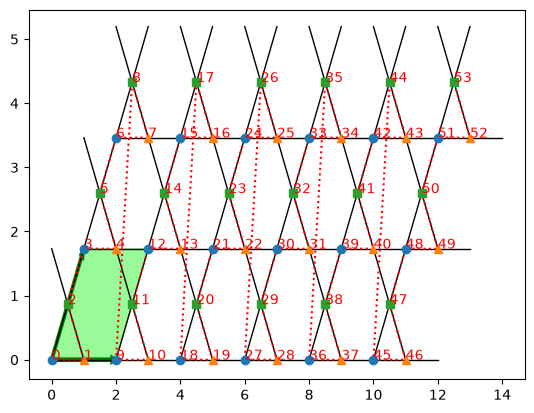

In [24]:
import matplotlib.pyplot as plt
from tenpy.models.lattice import Kagome

ax = plt.gca()
lat = Kagome(6,3, None, bc='periodic')
#help(lat)
lat.plot_coupling(ax, lat.pairs['nearest_neighbors'], linewidth=1.)
lat.plot_order(ax=ax, linestyle=':')
lat.plot_sites(ax=ax)
lat.plot_basis(ax, color='g', linewidth=2.)
plt.show()